Carga de datos

In [1]:
# Importar las librerias
import sqlite3
import glob
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

# Cargat desde la base SQLite
con = sqlite3.connect("../db/tfm_vocs.db")
muestras = pd.read_sql("SELECT * FROM muestras", con)
compuestos = pd.read_sql("SELECT * FROM compuestos", con)
con.close()

# Cargar los 6 parquet de abundancias
abundancias = pd.concat(
    [pd.read_parquet(f) for f in glob.glob("../db/data/processed/*.parquet")],
    ignore_index=True
)

print(f"muestras: {muestras.shape}")
print(f"compuestos: {compuestos.shape}")
print(f"abundancias: {abundancias.shape}")

# Comprobar el tipo de formato de las variables

print(f"\ndtypes de muestras:\n{muestras.dtypes}")

# Frecuencia de las clases de la variable objetivo
print(f"\nLa frecuencia de cada estado fisiologico es: \n{muestras['physiological_state'].value_counts()}")

muestras: (294, 19)
compuestos: (297, 15)
abundancias: (10363, 4)

dtypes de muestras:
sample_id                   str
species                     str
genotype                    str
genotype_notes              str
microorganism               str
strain                   object
physiological_state         str
dataset_origin              str
doi                         str
analytical_technique        str
timepoint                   str
tissue                      str
experiment_replicate    float64
biological_replicate    float64
load_date                   str
validation_status           str
intended_use                str
eje_biologico               str
metadata_extra              str
dtype: object

La frecuencia de cada estado fisiologico es: 
physiological_state
control                  103
infected                  64
herbivory_exposed         50
herbivory_only            15
infected_bacterial        14
herbivory_caterpillar     12
herbivory_aphid           11
infected_fungal      

Construcción de Matriz

In [2]:
# Unir abundancias con el catalogo de compuestos
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid", "dataset_origin"]],
    on="compuesto_id",
    how="left"
)

# Contar filas de abundancia sin CID 
print(f"Filas de abundancia sin pubchem_cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

# Descartar las que no tienen CID
abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)


# Pivotear la tabla: filas = muestras, columnas = pubchem_cid, valores = abundancia
# Revisar con aggfunc='mean', si se repite un CID para una misma muesta
matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN en la matriz (compuestos no medidos en esa muestra): {matriz_features.isna().sum().sum()}")
print(f"Proporcion de NaN: {matriz_features.isna().mean().mean():.2%}")

Filas de abundancia sin pubchem_cid: 1598 de 10363

matriz_features: (294, 197)
Total de NaN en la matriz (compuestos no medidos en esa muestra): 49589
Proporcion de NaN: 85.62%


In [3]:
# Antes de aceptar el drop de filas sin CID, verifico de que dataset vienen

sin_cid = abundancias_cid_completo = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid", "dataset_origin", "identified"]],
    on="compuesto_id",
    how="left"
)
sin_cid = sin_cid[sin_cid["pubchem_cid"].isna()]

print("Filas sin CID, por dataset de origen:")
print(sin_cid["dataset_origin"].value_counts())

print("\nDe esas filas sin CID, cuantas tenian 'identified' = False (compuesto no identificado):")
print(sin_cid["identified"].value_counts(dropna=False))

Filas sin CID, por dataset de origen:
dataset_origin
Lazazzara2018    1568
Alinc2026          30
Name: count, dtype: int64

De esas filas sin CID, cuantas tenian 'identified' = False (compuesto no identificado):
identified
0    1598
Name: count, dtype: int64


In [4]:
# Hay filas identified=True pero sin CID (de que dataset vienen y que compuestos son)
inconsistentes = sin_cid[sin_cid["identified"] == 1]

print("Dataset de origen de las filas 'identified=True' sin CID:")
print(inconsistentes["dataset_origin"].value_counts())

# Traigo los nombres de esos compuestospara revisar
nombres_inconsistentes = compuestos[
    compuestos["compuesto_id"].isin(inconsistentes["compuesto_id"].unique())
][["compuesto_id", "name_original", "cas", "identified", "pubchem_cid", "dataset_origin"]]

print(f"\nCompuestos unicos afectados: {nombres_inconsistentes.shape[0]}")
print(nombres_inconsistentes.to_string(index=False))

Dataset de origen de las filas 'identified=True' sin CID:
Series([], Name: count, dtype: int64)

Compuestos unicos afectados: 0
Empty DataFrame
Columns: [compuesto_id, name_original, cas, identified, pubchem_cid, dataset_origin]
Index: []


In [5]:
# CompletAR los 3 CIDs que quedaron pendientes 
con = sqlite3.connect("../db/tfm_vocs.db")
cur = con.cursor()

cids_pendientes = {
    "lazazzara2018_cmp022": 595385,
    "alinc2026_cmp003": 576718,   
    "alinc2026_cmp015": 7462,
}

for compuesto_id, cid in cids_pendientes.items():
    cur.execute(
        "UPDATE compuestos SET pubchem_cid = ? WHERE compuesto_id = ?",
        (cid, compuesto_id)
    )

con.commit()

# VerificRo que ya no queden identified=True sin CID
verificacion = pd.read_sql(
    "SELECT COUNT(*) as n FROM compuestos WHERE identified = 1 AND pubchem_cid IS NULL",
    con
)
con.close()

print(f"Compuestos identified=True sin CID: {verificacion['n'].iloc[0]}")

Compuestos identified=True sin CID: 0


In [6]:
# Cargar compuestos desde la base corregida
con = sqlite3.connect("../db/tfm_vocs.db")
compuestos = pd.read_sql("SELECT * FROM compuestos", con)
con.close()

print(f"Compuestos identified=True sin CID: {((compuestos['identified']==1) & (compuestos['pubchem_cid'].isna())).sum()}")

Compuestos identified=True sin CID: 0


In [7]:
# Unir abundancias con el catalogo de compuestos
abundancias_cid = abundancias.merge(
    compuestos[["compuesto_id", "pubchem_cid", "dataset_origin"]],
    on="compuesto_id",
    how="left"
)

# Contar filas de abundancia sin CID 
print(f"Filas de abundancia sin pubchem_cid: {abundancias_cid['pubchem_cid'].isna().sum()} de {len(abundancias_cid)}")

# Descartar las que no tienen CID
abundancias_cid = abundancias_cid.dropna(subset=["pubchem_cid"])
abundancias_cid["pubchem_cid"] = abundancias_cid["pubchem_cid"].astype(int)


# Pivotear la tabla: filas = muestras, columnas = pubchem_cid, valores = abundancia
# Revisar con aggfunc='mean', si se repite un CID para una misma muesta
matriz_features = abundancias_cid.pivot_table(
    index="sample_id",
    columns="pubchem_cid",
    values="abundancia",
    aggfunc="mean"
)

print(f"\nmatriz_features: {matriz_features.shape}")
print(f"Total de NaN en la matriz (compuestos no medidos en esa muestra): {matriz_features.isna().sum().sum()}")
print(f"Proporcion de NaN: {matriz_features.isna().mean().mean():.2%}")

Filas de abundancia sin pubchem_cid: 1598 de 10363

matriz_features: (294, 197)
Total de NaN en la matriz (compuestos no medidos en esa muestra): 49589
Proporcion de NaN: 85.62%


In [8]:
# En cuantas muestras esta medido cada compuesto (no-NaN)
cobertura_por_compuesto = matriz_features.notna().sum().sort_values(ascending=False)

print("Distribucion de cobertura (en cuantas muestras aparece cada compuesto):")
print(cobertura_por_compuesto.describe())

print("\nCompuestos medidos en al menos 30 muestras:")
print((cobertura_por_compuesto >= 30).sum())

print("\nCompuestos medidos en al menos 60 muestras:")
print((cobertura_por_compuesto >= 60).sum())

print("\nTop 15 compuestos con mayor cobertura:")
print(cobertura_por_compuesto.head(15))

Distribucion de cobertura (en cuantas muestras aparece cada compuesto):
count    197.000000
mean      42.279188
std       44.302511
min        5.000000
25%       14.000000
50%       15.000000
75%       60.000000
max      245.000000
dtype: float64

Compuestos medidos en al menos 30 muestras:
66

Compuestos medidos en al menos 60 muestras:
55

Top 15 compuestos con mayor cobertura:
pubchem_cid
8175       245
31289      225
6549       198
5281515    189
31253      188
240        149
11463      128
6054       127
998        127
9895       127
5281516    120
957        113
244        113
23204      113
18554      113
dtype: int64


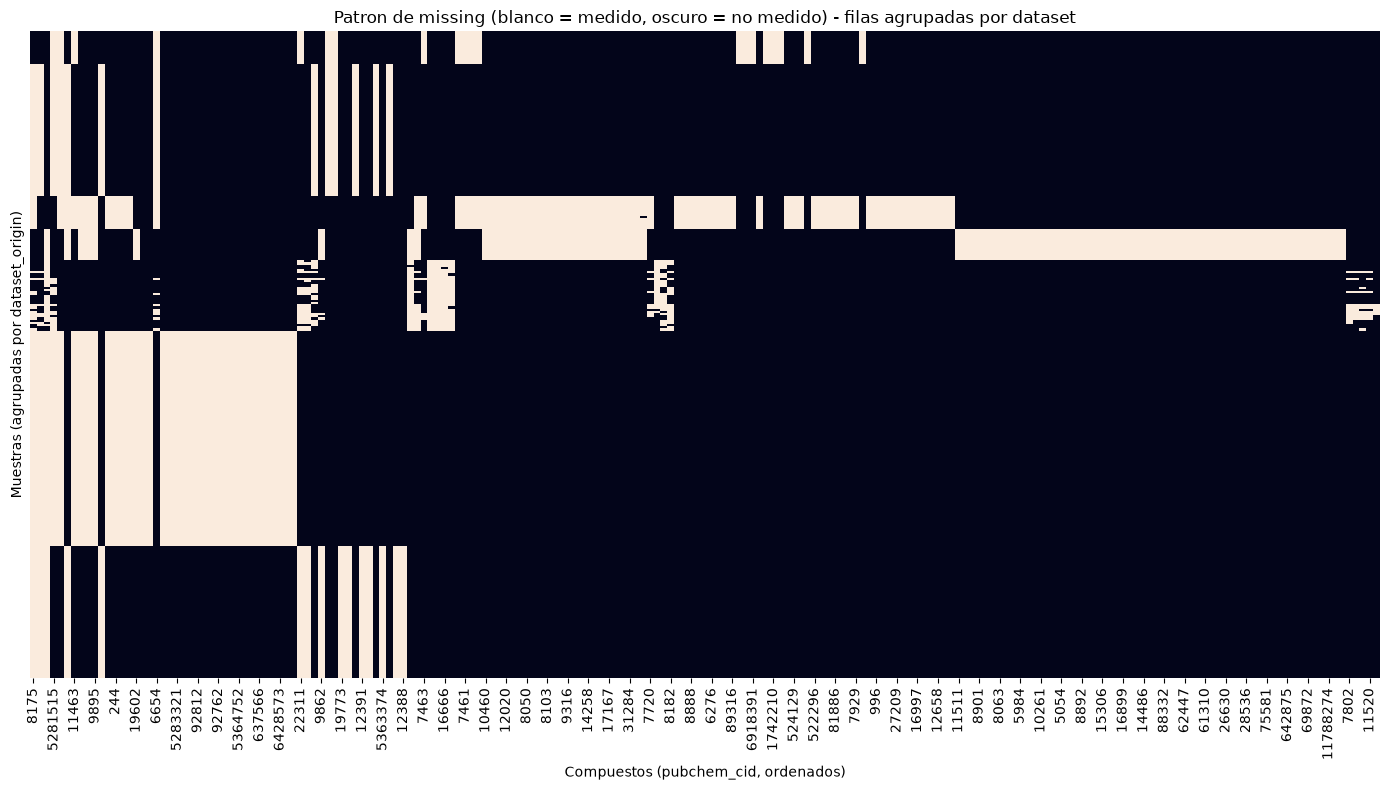

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ordenar columnas por cobertura (de mas a menos medido)
orden_columnas = matriz_features.notna().sum().sort_values(ascending=False).index
matriz_ordenada = matriz_features[orden_columnas]

# Agregar el dataset_origin de cada muestra para ver si el patron de missing se agrupa por fuente
origen_por_muestra = muestras.set_index("sample_id")["dataset_origin"]
orden_filas = origen_por_muestra.sort_values().index
matriz_ordenada = matriz_ordenada.reindex(orden_filas)

plt.figure(figsize=(14, 8))
sns.heatmap(matriz_ordenada.notna(), cbar=False, yticklabels=False)
plt.title("Patron de missing (blanco = medido, oscuro = no medido) - filas agrupadas por dataset")
plt.xlabel("Compuestos (pubchem_cid, ordenados)")
plt.ylabel("Muestras (agrupadas por dataset_origin)")
plt.tight_layout()
plt.show()

Este gráfico muestra que el patrón de missings está estructurado en bloques por los dataset, no es aleatorio. Hay bajo efecto solapamiento entre fuentes, por lo que no puede gtratarse como imputación estándar, porque no representa dato no encontrado si no que compuesto no estudiado.


*Normalización (z-score)*

In [10]:
# Estandarizor cada compuesto dentro de cada dataset por separado (no entre datasets)

matriz_zscore = matriz_features.copy()

# Generor una lista con los datasets de origen presentes
datasets_origen = list(muestras["dataset_origin"].unique())
print(f"Datasets de origen: {datasets_origen}")

Datasets de origen: ['Lazazzara2018', 'Laupheimer2024', 'Alinc2026', 'Moreira2024', 'Ghosh2022', 'Ayelo2026']


In [11]:
for dataset in datasets_origen:
    # Seleccionar los sample_id que pertenecen a este dataset
    ids_dataset = muestras.loc[muestras["dataset_origin"] == dataset, "sample_id"]

    # Calcular media y desvio de cada compuesto, usando solo las muestras de este dataset
    media = matriz_zscore.loc[ids_dataset].mean()
    desvio = matriz_zscore.loc[ids_dataset].std()

    # Aplicar la formula de estandarizacion: (x - media) / desvio
    matriz_zscore.loc[ids_dataset] = (matriz_zscore.loc[ids_dataset] - media) / desvio

# Comprobar cuantos NaN quedaron, deberian ser los mismos que antes
print(f"NaN antes del z-score: {matriz_features.isna().sum().sum()}")
print(f"NaN despues del z-score: {matriz_zscore.isna().sum().sum()}")

NaN antes del z-score: 49589
NaN despues del z-score: 49589


In [12]:
# Versión paraXGBoost
matriz_xgb = matriz_zscore.copy()
print(f"matriz_xgb: {matriz_xgb.shape}")

matriz_xgb: (294, 197)


In [13]:
#Versión para RandoForest
# Imputor con 0 
matriz_rf = matriz_zscore.fillna(0)

# Agregar una columna binaria por compuesto
indicador_medido = matriz_features.notna().astype(int)
indicador_medido.columns = [f"{c}_medido" for c in indicador_medido.columns]

matriz_rf = pd.concat([matriz_rf, indicador_medido], axis=1)
print(f"matriz_rf: {matriz_rf.shape}")

matriz_rf: (294, 394)


Separación del caso cualitativo (dataset de TH2) y codificación de variables

In [14]:
# Unir la matriz de features con la variable objetivo
datos_modelo = muestras.set_index("sample_id")[["species", "physiological_state"]].join(matriz_xgb)

# Separo el caso cualitativo (TH2) del clasificador cuantitativo
caso_cualitativo = datos_modelo[datos_modelo["physiological_state"] == "biocontrol_herbivory"]
datos_modelo = datos_modelo[datos_modelo["physiological_state"] != "biocontrol_herbivory"]

print(f"Muestras para el clasificador cuantitativo: {datos_modelo.shape[0]}")
print(f"Muestras del caso cualitativo: {caso_cualitativo.shape[0]}")


# ConVERTIR species en dummies
datos_modelo = pd.get_dummies(datos_modelo, columns=["species"], drop_first=True)

# Separar las variables predictoras y la variable de respuesta
X = datos_modelo.drop("physiological_state", axis=1)
y = datos_modelo["physiological_state"]

# Convertir los nombres de columna a string
X.columns = X.columns.astype(str)

print(f"\nLa frecuencia de cada clase es: \n{y.value_counts(normalize=True)}")

Muestras para el clasificador cuantitativo: 289
Muestras del caso cualitativo: 5

La frecuencia de cada clase es: 
physiological_state
control                  0.356401
infected                 0.221453
herbivory_exposed        0.173010
herbivory_only           0.051903
infected_bacterial       0.048443
herbivory_caterpillar    0.041522
herbivory_aphid          0.038062
infected_fungal          0.038062
infected_viral           0.031142
Name: proportion, dtype: float64


### Arbol de decisión

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=123
)


print(f"La frecuencia de cada clase en train es: \n{y_train.value_counts(normalize=True)}")
print(f"\nLa frecuencia de cada clase en test es: \n{y_test.value_counts(normalize=True)}")

print(f"\nTamaño de train: {X_train.shape[0]}")
print(f"Tamaño de test: {X_test.shape[0]}")

La frecuencia de cada clase en train es: 
physiological_state
control                  0.354978
infected                 0.220779
herbivory_exposed        0.173160
herbivory_only           0.051948
infected_bacterial       0.047619
herbivory_caterpillar    0.043290
herbivory_aphid          0.038961
infected_fungal          0.038961
infected_viral           0.030303
Name: proportion, dtype: float64

La frecuencia de cada clase en test es: 
physiological_state
control                  0.362069
infected                 0.224138
herbivory_exposed        0.172414
infected_bacterial       0.051724
herbivory_only           0.051724
infected_fungal          0.034483
herbivory_caterpillar    0.034483
infected_viral           0.034483
herbivory_aphid          0.034483
Name: proportion, dtype: float64

Tamaño de train: 231
Tamaño de test: 58


In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Creor el arbol de decision
base_classifier = DecisionTreeClassifier(min_samples_split=10, criterion="gini", max_depth=5, random_state=123)
base_classifier.fit(X_train, y_train)
y_pred_base = base_classifier.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy_base = accuracy_score(y_test, y_pred_base)
print(f"Precision del arbol estandar: {accuracy_base}")

print(f"\n{classification_report(y_test, y_pred_base, zero_division=0)}")

Precision del arbol estandar: 0.46551724137931033

                       precision    recall  f1-score   support

              control       0.42      0.48      0.44        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.00      0.00      0.00         2
    herbivory_exposed       0.89      0.80      0.84        10
       herbivory_only       1.00      0.67      0.80         3
             infected       0.15      0.15      0.15        13
   infected_bacterial       0.38      1.00      0.55         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       1.00      1.00      1.00         2

             accuracy                           0.47        58
            macro avg       0.43      0.46      0.42        58
         weighted avg       0.44      0.47      0.44        58



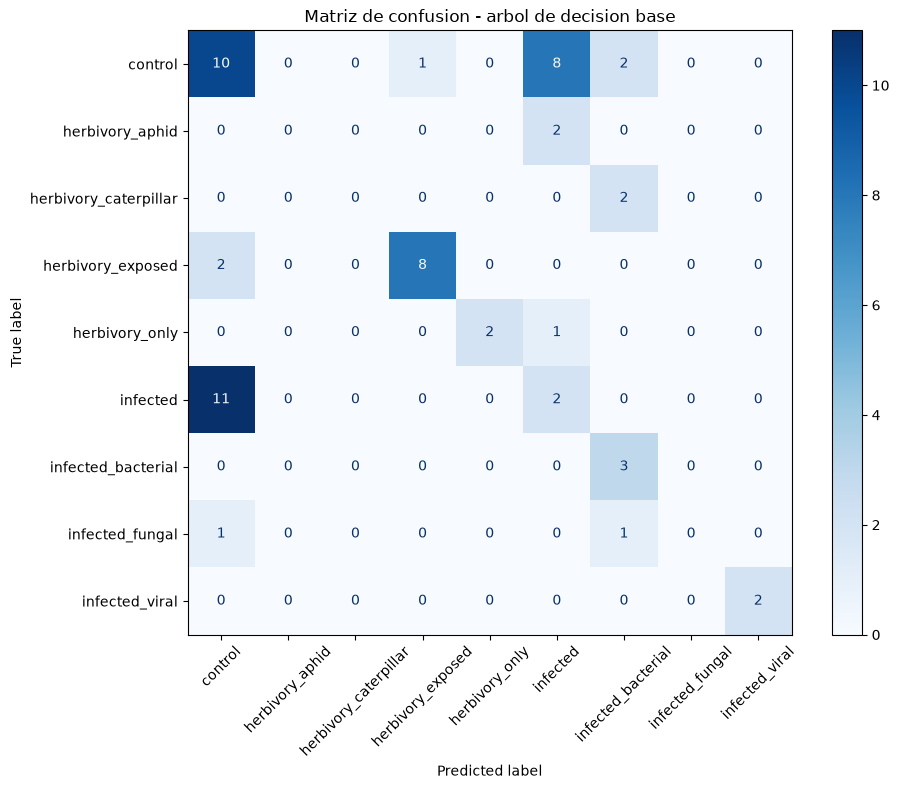

In [17]:
#Matriz de confusión
from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    base_classifier, X_test, y_test,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusion - arbol de decision base")
plt.tight_layout()
plt.show()

Analisis de la matriz de confusion - arbol base

 `infected` (cebada+vid, biotrofos) se confunde masivamente con `control` (11/13). 
Posible causa: agrupar dos especies distintas bajo un mismo estado puede ser demasiado heterogeneo para un
arbol simple - el perfil VOC de oidio en cebada y mildiu en vid quizas no comparten suficiente señal comun.


`herbivory_caterpillar` se confunde con `infected_bacterial` - ambas son Brassica rapa / Moreira2024 (mismo dataset),
pero estados distintos. Si el modelo solo memorizara el origen del estudio, no deberia confundir dos
estados de una misma fuente.

`herbivory_aphid` (Brassica) se predice como `infected` (Hordeum/Vitis) - confusion entre datasets
distintos, mas dificil de interpretar limpiamente.


### Random forest

In [18]:
# Armar el dataset para RF, con la matriz imputada 
datos_modelo_rf = muestras.set_index("sample_id")[["species", "physiological_state"]].join(matriz_rf)
datos_modelo_rf = datos_modelo_rf[datos_modelo_rf["physiological_state"] != "biocontrol_herbivory"]
datos_modelo_rf = pd.get_dummies(datos_modelo_rf, columns=["species"], drop_first=True)

X_rf = datos_modelo_rf.drop("physiological_state", axis=1)
X_rf.columns = X_rf.columns.astype(str)
y_rf = datos_modelo_rf["physiological_state"]

# Usar el mismo random_state que en el split anterior, para que train/test sean las mismas muestras
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_rf, test_size=0.2, stratify=y_rf, random_state=123
)

print(f"X_rf: {X_rf.shape}")
print(f"y_train_rf es igual a y_train: {(y_train_rf.values == y_train.values).all()}")

X_rf: (289, 399)
y_train_rf es igual a y_train: True


In [19]:
from sklearn.ensemble import RandomForestClassifier

# construir random forest
RF_model = RandomForestClassifier(
    n_estimators=60, bootstrap=True, max_depth=20,
    min_samples_split=10, criterion="entropy", min_samples_leaf=10,
    random_state=123
)
RF_model.fit(X_train_rf, y_train_rf)
y_pred_rf = RF_model.predict(X_test_rf)

# Evaluar el rendimiento del modelo
accuracy_rf = accuracy_score(y_test_rf, y_pred_rf)
print(f"Precision del modelo con RF estandar: {accuracy_rf}")

print(f"\n{classification_report(y_test_rf, y_pred_rf, zero_division=0)}")

Precision del modelo con RF estandar: 0.46551724137931033

                       precision    recall  f1-score   support

              control       0.44      0.71      0.55        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.00      0.00      0.00         2
    herbivory_exposed       0.83      1.00      0.91        10
       herbivory_only       0.00      0.00      0.00         3
             infected       1.00      0.08      0.14        13
   infected_bacterial       0.20      0.33      0.25         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       0.00      0.00      0.00         2

             accuracy                           0.47        58
            macro avg       0.27      0.24      0.21        58
         weighted avg       0.54      0.47      0.40        58



In [20]:
# Balancear las clases chcias
RF_model_balanced = RandomForestClassifier(
    n_estimators=60, bootstrap=True, max_depth=20,
    min_samples_split=10, criterion="entropy", min_samples_leaf=10,
    class_weight="balanced",
    random_state=123
)
RF_model_balanced.fit(X_train_rf, y_train_rf)
y_pred_rf_balanced = RF_model_balanced.predict(X_test_rf)

accuracy_rf_balanced = accuracy_score(y_test_rf, y_pred_rf_balanced)
print(f"Precision del modelo con RF balanceado: {accuracy_rf_balanced}")

print(f"\n{classification_report(y_test_rf, y_pred_rf_balanced, zero_division=0)}")

Precision del modelo con RF balanceado: 0.4482758620689655

                       precision    recall  f1-score   support

              control       0.00      0.00      0.00        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.25      0.50      0.33         2
    herbivory_exposed       0.83      1.00      0.91        10
       herbivory_only       0.17      0.33      0.22         3
             infected       0.52      0.85      0.65        13
   infected_bacterial       0.25      0.33      0.29         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       0.29      1.00      0.44         2

             accuracy                           0.45        58
            macro avg       0.26      0.45      0.32        58
         weighted avg       0.30      0.45      0.35        58



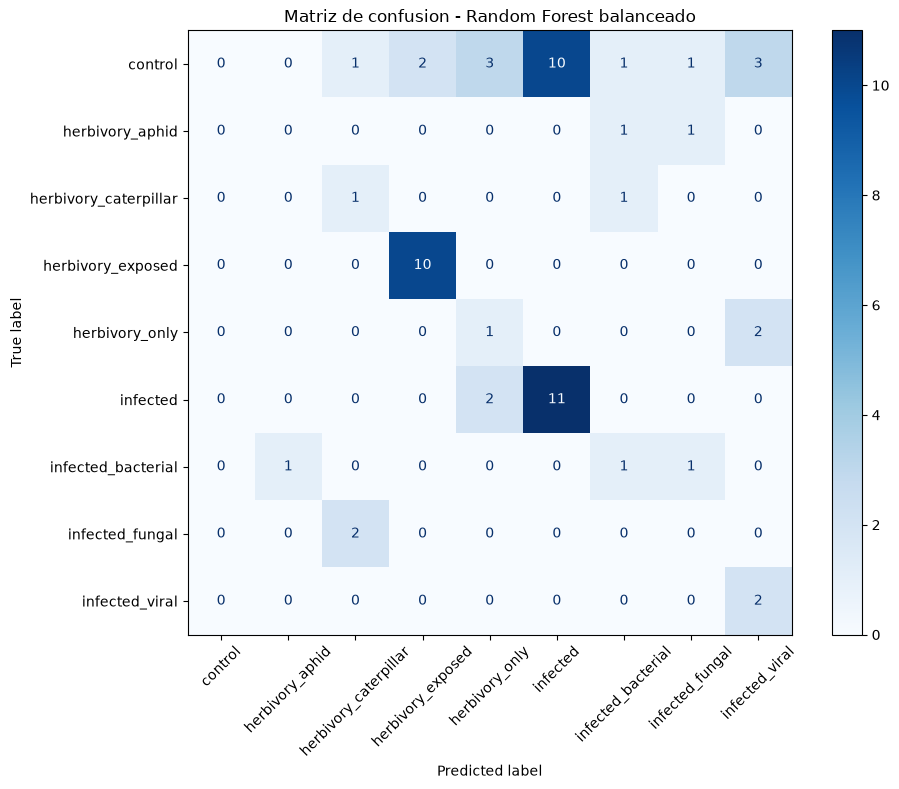

In [21]:
# Matriz de confusión
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    RF_model_balanced, X_test_rf, y_test_rf,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusion - Random Forest balanceado")
plt.tight_layout()
plt.show()

### Analisis de la matriz de confusion - random forest
El problema sigue siendo ´çontrol´ e ´infected´ (cebada + vid) no se distinguen bien  

In [22]:
#ver a que columnas le da importancia el modelo
importancias = pd.Series(RF_model_balanced.feature_importances_, index=X_train_rf.columns)
importancias_ordenadas = importancias.sort_values(ascending=False)



print("\nTop 15 features mas importantes:")
print(importancias_ordenadas.head(15))


Top 15 features mas importantes:
19773_medido      0.056336
12391_medido      0.048530
9862_medido       0.045912
10407_medido      0.041889
22311_medido      0.038883
12389_medido      0.032885
12388_medido      0.026865
19800_medido      0.026231
6429302_medido    0.026206
6054_medido       0.024182
240_medido        0.024040
8139_medido       0.021211
19800             0.017824
460_medido        0.016611
8181_medido       0.016222
dtype: float64


ESta tomando el indicador binario en vez de las abundancias como feature. NO esta aprendiendo control vs infectado. Entreno de nuevo pero exculyendo esas col

In [23]:
cols_sin_indicador = [c for c in X_train_rf.columns if not c.endswith("_medido")]

X_train_rf2 = X_train_rf[cols_sin_indicador]
X_test_rf2 = X_test_rf[cols_sin_indicador]

RF_model_sin_indicador = RandomForestClassifier(
    n_estimators=60, bootstrap=True, max_depth=20,
    min_samples_split=10, criterion="entropy", min_samples_leaf=10,
    class_weight="balanced",
    random_state=123
)
RF_model_sin_indicador.fit(X_train_rf2, y_train_rf)
y_pred_sin_indicador = RF_model_sin_indicador.predict(X_test_rf2)

print(f"Precision sin columnas _medido: {accuracy_score(y_test_rf, y_pred_sin_indicador)}")
print(f"\n{classification_report(y_test_rf, y_pred_sin_indicador, zero_division=0)}")

Precision sin columnas _medido: 0.4482758620689655

                       precision    recall  f1-score   support

              control       0.50      0.05      0.09        21
      herbivory_aphid       0.33      0.50      0.40         2
herbivory_caterpillar       0.20      0.50      0.29         2
    herbivory_exposed       0.83      1.00      0.91        10
       herbivory_only       0.23      1.00      0.38         3
             infected       0.50      0.54      0.52        13
   infected_bacterial       0.50      0.67      0.57         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       0.25      0.50      0.33         2

             accuracy                           0.45        58
            macro avg       0.37      0.53      0.39        58
         weighted avg       0.50      0.45      0.39        58



In [24]:
# restringir a los compuestos que se midieron en 2 o + dataset
# Identificar los CID 
cobertura_datasets_por_cid = abundancias_cid.groupby("pubchem_cid")["dataset_origin"].nunique()
cids_compartidos = cobertura_datasets_por_cid[cobertura_datasets_por_cid >= 2].index.astype(str)

print(f"CIDs compartidos entre 2+ datasets: {len(cids_compartidos)}")

cols_compartidas = [c for c in cids_compartidos if c in X_train_rf.columns]
cols_species = [c for c in X_train_rf.columns if c.startswith("species_")]
cols_compartidas_y_especie = cols_compartidas + cols_species

X_train_compartido = X_train_rf[cols_compartidas_y_especie]
X_test_compartido = X_test_rf[cols_compartidas_y_especie]

RF_model_compartido = RandomForestClassifier(
    n_estimators=60, bootstrap=True, max_depth=20,
    min_samples_split=10, criterion="entropy", min_samples_leaf=10,
    class_weight="balanced",
    random_state=123
)
RF_model_compartido.fit(X_train_compartido, y_train_rf)
y_pred_compartido = RF_model_compartido.predict(X_test_compartido)

print(f"Precision con compuestos compartidos + especie: {accuracy_score(y_test_rf, y_pred_compartido)}")
print(f"\n{classification_report(y_test_rf, y_pred_compartido, zero_division=0)}")

CIDs compartidos entre 2+ datasets: 31
Precision con compuestos compartidos + especie: 0.3793103448275862

                       precision    recall  f1-score   support

              control       0.00      0.00      0.00        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.00      0.00      0.00         2
    herbivory_exposed       0.83      1.00      0.91        10
       herbivory_only       0.22      0.67      0.33         3
             infected       0.47      0.62      0.53        13
   infected_bacterial       0.00      0.00      0.00         3
      infected_fungal       0.17      0.50      0.25         2
       infected_viral       0.20      0.50      0.29         2

             accuracy                           0.38        58
            macro avg       0.21      0.36      0.26        58
         weighted avg       0.27      0.38      0.31        58



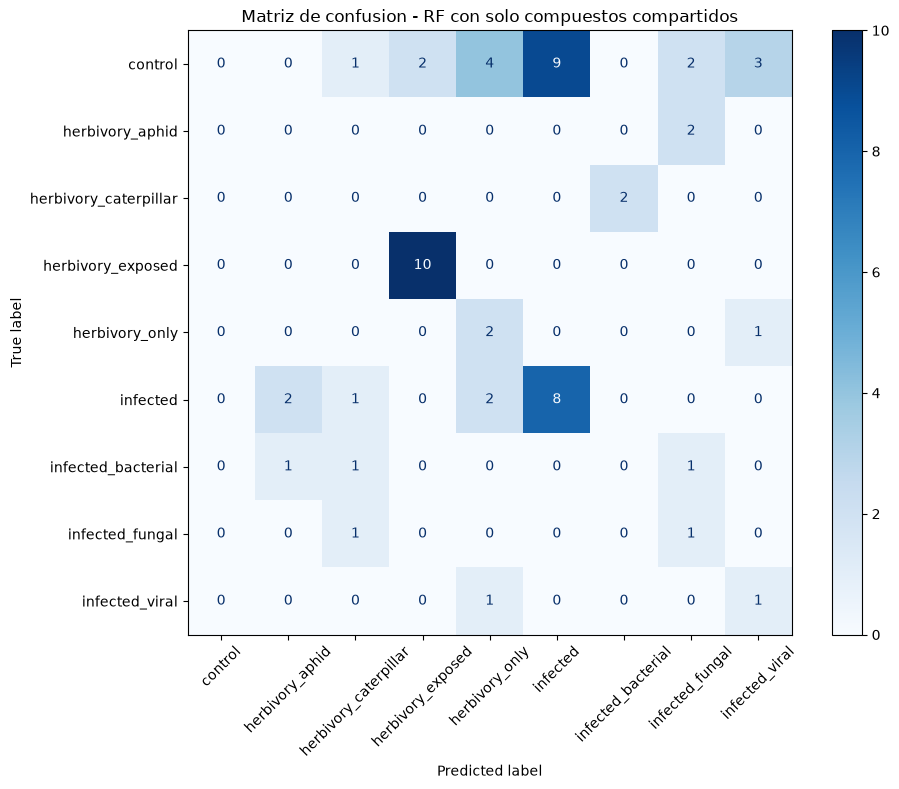

In [25]:
# Matriz de conf.
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    RF_model_compartido, X_test_compartido, y_test_rf,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusion - RF con solo compuestos compartidos")
plt.tight_layout()
plt.show()

### Conclusion sobre la confusion control/infected

Tras una serie de diagnosticos (arbol simple, RF con y sin balanceo, con y
sin indicador, restringido a compuestos compartidos entre estudios), se descarta que la
confusion `control` `infected` se deba a:
- Desbalance de clases (invirtio el error, no lo resolvio)
- Memorizacion de dataset (persiste incluso sin ningun feature que identifique el dataset de origen)

Es una limitacion biologica/temporal real: el  perfil VOC de infecciones biotrofas (oidio en cebada, mildiu en vid) se
solapa con el de plantas control, mientras que la infeccion necrotriofa (Sclerotinia en Brassica rapa, clase `infected_fungal`) 
muestra mejor separacion. Los patogenos biotrofos buscan mantener viva la celula huesped, e inducen una respuesta de defensa mas sutil que los necrotrofos.


## GRIDSEARCHCV - RANDOM FOREST

In [26]:
from sklearn.model_selection import GridSearchCV
# Seleccionar un grid
params_rf = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [5, 10, 20],
    "min_samples_leaf": [3, 10],
    "criterion": ["gini", "entropy"],
}

scoring_metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

# cv 
grid_search_RF = GridSearchCV(
    estimator=RandomForestClassifier(class_weight="balanced", random_state=123),
    param_grid=params_rf,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_RF.fit(X_train_rf, y_train_rf)

print(f"Mejores parametros: {grid_search_RF.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_RF.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 150}
Mejor f1_macro en CV: 0.46032160847090325


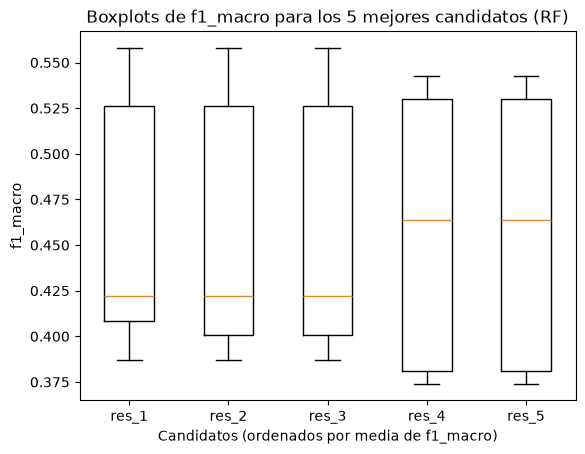

Parametros de cada candidato:
res_1: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 150}
res_2: {'criterion': 'entropy', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 150}
res_3: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 10, 'n_estimators': 150}
res_4: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}
res_5: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}


In [27]:
# Obtener los resultados del gs
resultados_cv = pd.DataFrame(grid_search_RF.cv_results_)

# Ordenar por la metrica de interes, me quedo con el top 5
sorted_results = resultados_cv.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

# Extraer el f1_macro de cada uno de los 5 folds, para cada uno de los 5 candidatos
res_1 = sorted_results[["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]].iloc[0]
res_2 = sorted_results[["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]].iloc[1]
res_3 = sorted_results[["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]].iloc[2]
res_4 = sorted_results[["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]].iloc[3]
res_5 = sorted_results[["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]].iloc[4]

# Boxplot 
plt.boxplot([res_1.values, res_2.values, res_3.values, res_4.values, res_5.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (RF)")
plt.xlabel("Candidatos (ordenados por media de f1_macro)")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada candidato:")
for i in range(5):
    print(f"res_{i+1}: {sorted_results['params'].iloc[i]}")

Elección: res_4 ofrece el mejor desempeño típico (mediana más alta) de los 5 candidatos, y la diferencia en su peor caso frente al grupo
más conservador (entropy) es marginal (~0.01 de f1_macro), no suficiente como para justificar sacrificar la mejora en la mediana. Lo
seleccione sobre res_1  porque el boxplot muestra que res_1, res_2 y res_3 son prácticamente indistinguibles entre sí, es decir,
el mejor resultado automático no reflejabauna ventaja real, sino redundancia entre 3 configuraciones equivalentes.

In [28]:
#Re entrenamiento manueal con el modelo seleccionado
# analizar su robustez a lo largo de cross validation.
from sklearn.metrics import f1_score

mejores_params_RF = sorted_results["params"].iloc[3]
print(f"Parametros elegidos: {mejores_params_RF}")


best_model_RF = RandomForestClassifier(**mejores_params_RF, class_weight="balanced", random_state=123)
best_model_RF.fit(X_train_rf, y_train_rf)

# Observar el posible sobreajuste comparando predicciones en train y test.
y_train_pred_rf = best_model_RF.predict(X_train_rf)
y_test_pred_rf = best_model_RF.predict(X_test_rf)

print(f"\nF1 macro en train: {f1_score(y_train_rf, y_train_pred_rf, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_rf, y_test_pred_rf, average='macro')}")


print(f"\n{classification_report(y_test_rf, y_test_pred_rf, zero_division=0)}")

Parametros elegidos: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 3, 'min_samples_split': 5, 'n_estimators': 150}

F1 macro en train: 0.8625565773396642
F1 macro en test: 0.41480639730639735

                       precision    recall  f1-score   support

              control       0.64      0.33      0.44        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.25      0.50      0.33         2
    herbivory_exposed       0.83      1.00      0.91        10
       herbivory_only       0.33      1.00      0.50         3
             infected       0.75      0.69      0.72        13
   infected_bacterial       0.33      0.33      0.33         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       0.50      0.50      0.50         2

             accuracy                           0.55        58
            macro avg       0.40      0.48      0.41        58
         weighted avg       0.60    

El modelo memoriza bastante el conjunto de entrenamiento.
El f1_macro en test (0.41) es bastante cercano al que  había dado el GridSearchCV en cross-validation (0.46), lo cual da algo de confianza en que la estimación de CV es representativa.
Control (0.44) e infected (0.72) mejoraron muchísimo respecto a todos los diagnósticos donde control estaba en 0.00, esto sugiere que se resolvía parcialmente con el ajuste correcto de hiperparámetros
Siguen en 0 las clases de n=2 (herbivory_aphid, infected_fungal), consistente con lo esperado.

## XGBoost

In [29]:
# Armar el dataset, con la matriz sin imputar 
datos_modelo_xgb = muestras.set_index("sample_id")[["species", "physiological_state"]].join(matriz_xgb)
datos_modelo_xgb = datos_modelo_xgb[datos_modelo_xgb["physiological_state"] != "biocontrol_herbivory"]
datos_modelo_xgb = pd.get_dummies(datos_modelo_xgb, columns=["species"], drop_first=True)

X_xgb = datos_modelo_xgb.drop("physiological_state", axis=1)
X_xgb.columns = X_xgb.columns.astype(str)
y_xgb = datos_modelo_xgb["physiological_state"]

# Mismo random_state que en los splits anteriores
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_xgb, y_xgb, test_size=0.2, stratify=y_xgb, random_state=123
)

print(f"X_xgb: {X_xgb.shape}")
print(f"Confirmo mismo split que los anteriores: {(y_train_xgb.values == y_train.values).all()}")

X_xgb: (289, 202)
Confirmo mismo split que los anteriores: True


In [30]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_train_xgb_enc = le.fit_transform(y_train_xgb)
y_test_xgb_enc = le.transform(y_test_xgb)

xgb_classifier = XGBClassifier(
    booster="gbtree", n_estimators=200,
    eta=0.1, gamma=1, max_depth=15,
    tree_method="hist", random_state=123
)
xgb_classifier.fit(X_train_xgb, y_train_xgb_enc)
y_pred_base_xgb = xgb_classifier.predict(X_test_xgb)

accuracy_xgb = accuracy_score(y_test_xgb_enc, y_pred_base_xgb)
print(f"Precision de XGBoost base: {accuracy_xgb}")

print(f"\n{classification_report(y_test_xgb_enc, y_pred_base_xgb, target_names=le.classes_, zero_division=0)}")

Precision de XGBoost base: 0.6379310344827587

                       precision    recall  f1-score   support

              control       0.57      0.76      0.65        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.25      0.50      0.33         2
    herbivory_exposed       0.91      1.00      0.95        10
       herbivory_only       0.67      0.67      0.67         3
             infected       0.86      0.46      0.60        13
   infected_bacterial       0.00      0.00      0.00         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       1.00      1.00      1.00         2

             accuracy                           0.64        58
            macro avg       0.47      0.49      0.47        58
         weighted avg       0.63      0.64      0.62        58



In [31]:
#Chequear sobreajuste
y_train_pred_xgb = xgb_classifier.predict(X_train_xgb)
y_test_pred_xgb = xgb_classifier.predict(X_test_xgb)

print(f"Accuracy en train: {accuracy_score(y_train_xgb_enc, y_train_pred_xgb)}")
print(f"Accuracy en test: {accuracy_score(y_test_xgb_enc, y_test_pred_xgb)}")

Accuracy en train: 0.9826839826839827
Accuracy en test: 0.6379310344827587


In [32]:
## GridSearch

params_xgb = {
    "n_estimators": [100, 150, 200],
    "eta": [0.05, 0.1, 0.2],
    "gamma": [0.1, 0.5, 1],
    "max_depth": [3, 5, 8],
}

scoring_metrics = ["accuracy", "precision_macro", "recall_macro", "f1_macro"]

grid_search_XGB = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB.fit(X_train_xgb, y_train_xgb_enc)

print(f"Mejores parametros: {grid_search_XGB.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150}
Mejor f1_macro en CV: 0.5250168640262075


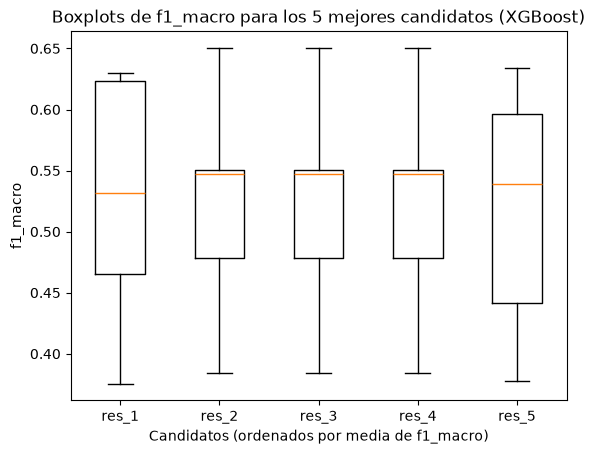

Parametros de cada candidato:
res_1x: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150}
res_2x: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 100}
res_3x: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 150}
res_4x: {'eta': 0.2, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 200}
res_5x: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 5, 'n_estimators': 150}


In [33]:
#proceso de selección top 5
resultados_cv_xgb = pd.DataFrame(grid_search_XGB.cv_results_)

sorted_results_xgb = resultados_cv_xgb.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

cols_folds = ["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]

res_1x = sorted_results_xgb[cols_folds].iloc[0]
res_2x = sorted_results_xgb[cols_folds].iloc[1]
res_3x = sorted_results_xgb[cols_folds].iloc[2]
res_4x = sorted_results_xgb[cols_folds].iloc[3]
res_5x = sorted_results_xgb[cols_folds].iloc[4]

plt.boxplot([res_1x.values, res_2x.values, res_3x.values, res_4x.values, res_5x.values],
            tick_labels=["res_1","res_2","res_3","res_4","res_5"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost)")
plt.xlabel("Candidatos (ordenados por media de f1_macro)")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada candidato:")
for i in range(5):
    print(f"res_{i+1}x: {sorted_results_xgb['params'].iloc[i]}")

res_1x es el más claro, tiene una de las medianas más altas, y la caja más angosta (menor dispersión). Además, es el que había ganado por refit automático.

In [34]:
#Re entrenar el modelo con los param elegidos
mejores_params_XGB = sorted_results_xgb["params"].iloc[0]
print(f"Parametros elegidos: {mejores_params_XGB}")

best_model_XGB = XGBClassifier(
    **mejores_params_XGB, booster="gbtree", tree_method="hist", random_state=123
)
best_model_XGB.fit(X_train_xgb, y_train_xgb_enc)

y_train_pred_xgb_best = best_model_XGB.predict(X_train_xgb)
y_test_pred_xgb_best = best_model_XGB.predict(X_test_xgb)

print(f"\nF1 macro en train: {f1_score(y_train_xgb_enc, y_train_pred_xgb_best, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_xgb_enc, y_test_pred_xgb_best, average='macro')}")


print(f"\n{classification_report(y_test_xgb_enc, y_test_pred_xgb_best, target_names=le.classes_, zero_division=0)}")

Parametros elegidos: {'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150}

F1 macro en train: 1.0
F1 macro en test: 0.5038986354775828

                       precision    recall  f1-score   support

              control       0.57      0.81      0.67        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       0.25      0.50      0.33         2
    herbivory_exposed       0.89      0.80      0.84        10
       herbivory_only       0.67      0.67      0.67         3
             infected       0.83      0.38      0.53        13
   infected_bacterial       1.00      0.33      0.50         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       1.00      1.00      1.00         2

             accuracy                           0.62        58
            macro avg       0.58      0.50      0.50        58
         weighted avg       0.67      0.62      0.61        58



In [35]:
#Intentar bajar el sobreajuste
## GS - XGBOOST CON REGULARIZACION
params_xgb_reg = {
    "n_estimators": [150],
    "eta": [0.05],
    "gamma": [0.1, 0.5],
    "max_depth": [2, 3],
    "reg_alpha": [0, 1],
    "reg_lambda": [1, 5],
    "subsample": [0.7, 1.0],
    "colsample_bytree": [0.5, 1.0],
}

grid_search_XGB_reg = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb_reg,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_reg.fit(X_train_xgb, y_train_xgb_enc)

print(f"Mejores parametros: {grid_search_XGB_reg.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_reg.best_score_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'colsample_bytree': 1.0, 'eta': 0.05, 'gamma': 0.1, 'max_depth': 3, 'n_estimators': 150, 'reg_alpha': 0, 'reg_lambda': 1, 'subsample': 1.0}
Mejor f1_macro en CV: 0.5250168640262075


In [36]:
# Seleccionar para reducir las features

# Usar la importancia de features del modelo XGBoost
importancias_xgb = pd.Series(best_model_XGB.feature_importances_, index=X_train_xgb.columns)
importancias_xgb = importancias_xgb.sort_values(ascending=False)

print("Top 20 features mas importantes:")
print(importancias_xgb.head(20))

print(f"\nCuantas features tienen importancia > 0: {(importancias_xgb > 0).sum()} de {len(importancias_xgb)}")

Top 20 features mas importantes:
7461       0.130386
18756      0.098826
26955      0.037950
7705       0.037718
6616       0.036473
11196      0.036378
441005     0.030659
240        0.028128
20307      0.024775
586292     0.022935
460        0.018406
6054       0.017745
12388      0.017308
556196     0.016670
16666      0.014338
31289      0.013974
7150       0.013916
6427110    0.013555
8139       0.013551
6782       0.013006
dtype: float32

Cuantas features tienen importancia > 0: 81 de 202


In [37]:
# Identificar los compuestos más importantes
top_cids = importancias_xgb.head(10).index.astype(int).tolist()

nombres_top = compuestos[compuestos["pubchem_cid"].isin(top_cids)][
    ["pubchem_cid", "name_original", "dataset_origin", "compound_class"]
].drop_duplicates(subset=["pubchem_cid"])

print(nombres_top.to_string(index=False))

 pubchem_cid                        name_original dataset_origin                               compound_class
    441005.0 delta-Cadinene (vitis berry_stem)_31  Lazazzara2018                                          NaN
      6616.0                             Camphene Laupheimer2024                                          NaN
      7461.0                      gamma terpinene      Alinc2026                                          NaN
       240.0                         Benzaldehyde    Moreira2024                                          NaN
     20307.0                      2,4-Heptadienal      Ghosh2022 Fatty acid derivatives/ Green leaf volatiles
    586292.0                          Anethofuran      Ghosh2022                                       Furans
     26955.0                          beta-Ionone      Ghosh2022                           Irregular terpenes
     11196.0             trans-2,cis-6-Nonadienal      Ghosh2022 Fatty acid derivatives/ Green leaf volatiles
      7705

In [38]:
print(f"CID 7461 (gamma-terpinene) esta en compartidos: {'7461' in cids_compartidos}")
print(f"CID 18756 (beta-ocimene) esta en compartidos: {'18756' in cids_compartidos}")

# Revisar cuantos de los TOP 20 son exclusivos de un solo dataset vs compartidos
top20_cids = importancias_xgb.head(20).index.astype(str)
exclusivos = [c for c in top20_cids if c not in cids_compartidos]
compartidos_top20 = [c for c in top20_cids if c in cids_compartidos]

print(f"\nDe los top 20, exclusivos de un dataset: {len(exclusivos)}")
print(f"De los top 20, compartidos entre 2+ datasets: {len(compartidos_top20)}")
print(f"\nCIDs exclusivos en el top 20: {exclusivos}")

CID 7461 (gamma-terpinene) esta en compartidos: True
CID 18756 (beta-ocimene) esta en compartidos: False

De los top 20, exclusivos de un dataset: 16
De los top 20, compartidos entre 2+ datasets: 4

CIDs exclusivos en el top 20: ['18756', '26955', '7705', '6616', '11196', '441005', '20307', '586292', '460', '12388', '556196', '16666', '7150', '6427110', '8139', '6782']


In [39]:
## XGBOOST - SOLO COMPUESTOS COMPARTIDOS

# Convertir a NaN los ceros que vienen de la imputacion de matriz_rf,


cols_compartidas_sin_especie = cols_compartidas  # ya definido ayer
cols_especie = [c for c in X_train_xgb.columns if c.startswith("species_")]
cols_finales = cols_compartidas_sin_especie + cols_especie

X_train_limpio = X_train_xgb[cols_finales]
X_test_limpio = X_test_xgb[cols_finales]

print(f"X_train_limpio: {X_train_limpio.shape}")

params_xgb_limpio = {
    "n_estimators": [100, 150, 200],
    "eta": [0.05, 0.1, 0.2],
    "gamma": [0.1, 0.5, 1],
    "max_depth": [2, 3, 5],
}

grid_search_XGB_limpio = GridSearchCV(
    estimator=XGBClassifier(booster="gbtree", tree_method="hist", random_state=123),
    param_grid=params_xgb_limpio,
    cv=5,
    scoring=scoring_metrics,
    refit="f1_macro"
)
grid_search_XGB_limpio.fit(X_train_limpio, y_train_xgb_enc)

print(f"Mejores parametros: {grid_search_XGB_limpio.best_params_}")
print(f"Mejor f1_macro en CV: {grid_search_XGB_limpio.best_score_}")

X_train_limpio: (231, 36)


C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Mejores parametros: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}
Mejor f1_macro en CV: 0.3764795619831455


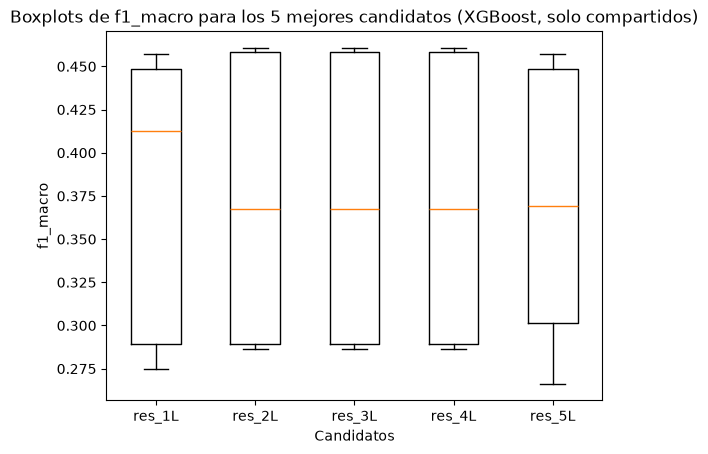

Parametros de cada candidato:
res_1L: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}
res_2L: {'eta': 0.2, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}
res_3L: {'eta': 0.2, 'gamma': 1, 'max_depth': 2, 'n_estimators': 200}
res_4L: {'eta': 0.2, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}
res_5L: {'eta': 0.1, 'gamma': 1, 'max_depth': 2, 'n_estimators': 150}


In [40]:
# Top 5
resultados_cv_limpio = pd.DataFrame(grid_search_XGB_limpio.cv_results_)
sorted_results_limpio = resultados_cv_limpio.sort_values(by="mean_test_f1_macro", ascending=False).head(5)

cols_folds = ["split0_test_f1_macro","split1_test_f1_macro","split2_test_f1_macro","split3_test_f1_macro","split4_test_f1_macro"]

res_1L = sorted_results_limpio[cols_folds].iloc[0]
res_2L = sorted_results_limpio[cols_folds].iloc[1]
res_3L = sorted_results_limpio[cols_folds].iloc[2]
res_4L = sorted_results_limpio[cols_folds].iloc[3]
res_5L = sorted_results_limpio[cols_folds].iloc[4]

plt.boxplot([res_1L.values, res_2L.values, res_3L.values, res_4L.values, res_5L.values],
            tick_labels=["res_1L","res_2L","res_3L","res_4L","res_5L"])
plt.title("Boxplots de f1_macro para los 5 mejores candidatos (XGBoost, solo compartidos)")
plt.xlabel("Candidatos")
plt.ylabel("f1_macro")
plt.show()

print("Parametros de cada candidato:")
for i in range(5):
    print(f"res_{i+1}L: {sorted_results_limpio['params'].iloc[i]}")

In [41]:
mejores_params_XGB_limpio = sorted_results_limpio["params"].iloc[0]
print(f"Parametros elegidos: {mejores_params_XGB_limpio}")

best_model_XGB_limpio = XGBClassifier(
    **mejores_params_XGB_limpio, booster="gbtree", tree_method="hist", random_state=123
)
best_model_XGB_limpio.fit(X_train_limpio, y_train_xgb_enc)

y_train_pred_limpio = best_model_XGB_limpio.predict(X_train_limpio)
y_test_pred_limpio = best_model_XGB_limpio.predict(X_test_limpio)

print(f"\nF1 macro en train: {f1_score(y_train_xgb_enc, y_train_pred_limpio, average='macro')}")
print(f"F1 macro en test: {f1_score(y_test_xgb_enc, y_test_pred_limpio, average='macro')}")
print("Notese la diferencia entre ambos conjuntos y el posible sobreajuste.")

print(f"\n{classification_report(y_test_xgb_enc, y_test_pred_limpio, target_names=le.classes_, zero_division=0)}")

Parametros elegidos: {'eta': 0.05, 'gamma': 1, 'max_depth': 2, 'n_estimators': 100}

F1 macro en train: 0.8861752445085779
F1 macro en test: 0.3630096483037659
Notese la diferencia entre ambos conjuntos y el posible sobreajuste.

                       precision    recall  f1-score   support

              control       0.37      0.52      0.43        21
      herbivory_aphid       0.00      0.00      0.00         2
herbivory_caterpillar       1.00      0.50      0.67         2
    herbivory_exposed       0.91      1.00      0.95        10
       herbivory_only       0.20      0.33      0.25         3
             infected       0.43      0.23      0.30        13
   infected_bacterial       0.00      0.00      0.00         3
      infected_fungal       0.00      0.00      0.00         2
       infected_viral       1.00      0.50      0.67         2

             accuracy                           0.47        58
            macro avg       0.43      0.34      0.36        58
         wei

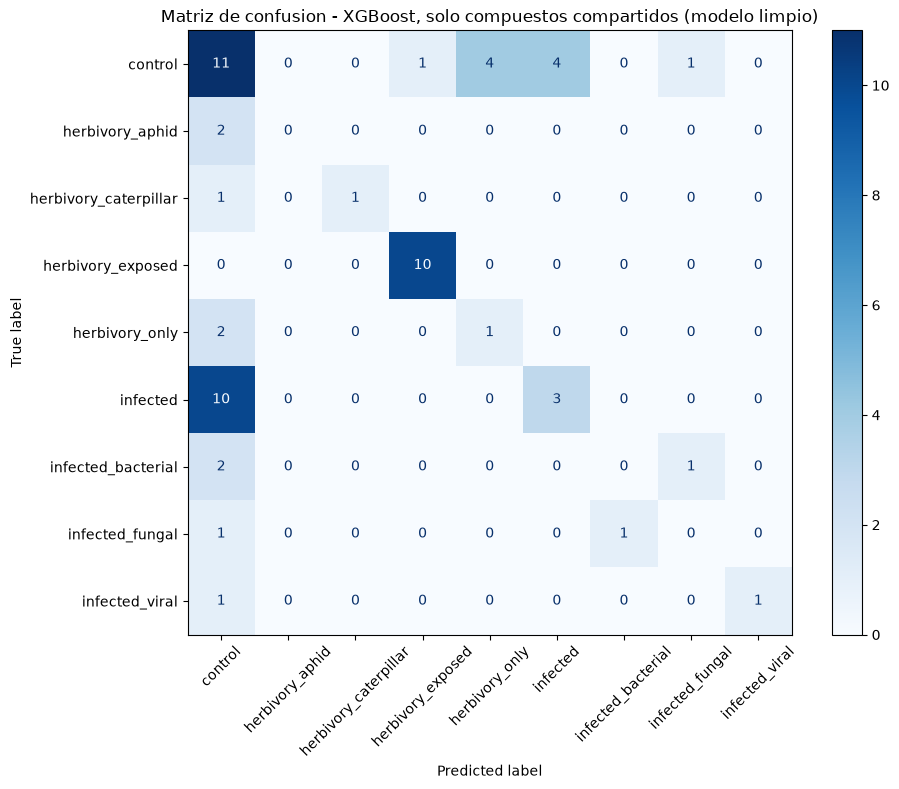

In [42]:
#MC
fig, ax = plt.subplots(figsize=(10, 8))
ConfusionMatrixDisplay.from_estimator(
    best_model_XGB_limpio, X_test_limpio, y_test_xgb_enc,
    display_labels=le.classes_,
    xticks_rotation=45,
    ax=ax,
    cmap="Blues"
)
plt.title("Matriz de confusion - XGBoost, solo compuestos compartidos (modelo limpio)")
plt.tight_layout()
plt.show()

## Modelo baseline final

Se adopta como modelo  el **XGBoost entrenado solo con los 31 compuestos compartidos entre 2+ datasets**
(`best_model_XGB_limpio`), no el entrenado con las 202 features completas, a pesar de rendir menos
(f1_macro test 0.36 vs 0.50).

El modelo de 202 features se apoya mayoritariamente (16 de sus 20 features mas importantes) 
en compuestos exclusivos de un solo dataset, lo cual lo hace indistinguible de memorizar el estudio de origen en lugar
de aprender biologia. El modelo de 31 features, aunque rinde menos, es el unico que puede sostener honestamente que su señal es quimica y no de
batch.

El modelo de 202 features se documenta como analisis complementario: la diferencia entre ambos (~0.14 de f1_macro) es una estimacion del "costo"
del efecto de batch en este dataset.

la matriz de confusion del modelo limpio reproduce el mismo patron `infected -> control` visto en los 4 modelos
anteriores (arbol, RF, XGBoost completo), es una limitacion biologica (infecciones biotrofas con perfil VOC solapado a control),
no un artefacto de un modelo en particular.

### SHAP

In [43]:
# SHAP

import shap

# TreeExplainer 
explainer = shap.TreeExplainer(best_model_XGB_limpio)

# Calcular los shap values sobre el conjunto de test
shap_values = explainer.shap_values(X_test_limpio)

print(f"Forma de shap_values: {np.array(shap_values).shape}")
print(f"Forma de X_test_limpio: {X_test_limpio.shape}")
print(f"Clases del modelo: {le.classes_}")

C:\Users\sofia\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Forma de shap_values: (58, 36, 9)
Forma de X_test_limpio: (58, 36)
Clases del modelo: ['control' 'herbivory_aphid' 'herbivory_caterpillar' 'herbivory_exposed'
 'herbivory_only' 'infected' 'infected_bacterial' 'infected_fungal'
 'infected_viral']


In [44]:
# promedio del valor absoluto de SHAP
shap_values_array = np.array(shap_values)  # (58, 36, 9)

# Para cada feature, promedio shap sobre muestras y clases
importancia_global = np.abs(shap_values_array).mean(axis=(0, 2))
importancia_global = pd.Series(importancia_global, index=X_test_limpio.columns).sort_values(ascending=False)

print("Top 15 features por importancia SHAP global (promedio sobre las 9 clases):")
print(importancia_global.head(15))

Top 15 features por importancia SHAP global (promedio sobre las 9 clases):
240                           0.327750
9862                          0.225090
species_Gossypium hirsutum    0.203543
12389                         0.154814
31289                         0.142704
5281516                       0.106895
22311                         0.104972
4133                          0.096528
6549                          0.052994
998                           0.043798
8175                          0.040357
5281520                       0.031012
7461                          0.027550
5363388                       0.024391
17868                         0.023111
dtype: float32


In [45]:
top_cids_shap = importancia_global.head(15).index
top_cids_shap_numericos = [c for c in top_cids_shap if c.isdigit()]

nombres_shap = compuestos[compuestos["pubchem_cid"].astype(str).isin(top_cids_shap_numericos)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])

print(nombres_shap.to_string(index=False))

Empty DataFrame
Columns: [pubchem_cid, name_original]
Index: []


In [46]:
# Cambiar tipos
top_cids_shap = importancia_global.head(15).index
top_cids_shap_numericos = [int(c) for c in top_cids_shap if c.isdigit()]

nombres_shap = compuestos[compuestos["pubchem_cid"].isin(top_cids_shap_numericos)][
    ["pubchem_cid", "name_original"]
].drop_duplicates(subset=["pubchem_cid"])

print(nombres_shap.to_string(index=False))


 pubchem_cid                                                          name_original
      6549.0 beta-Linalool (vitis whole plant_leave_berry_flower_stem_skin_mesh)_27
     31289.0            Nonanal (vitis whole plant_leave_flower_berry_skin_stem)_12
      8175.0                        Decanal (vitis stem_leave_berry_whole plant)_16
       998.0                              Benzeneacetaldehyde (vitis berry_stem)_26
   5363388.0                                                  (Z)-3-Hexenyl acetate
      9862.0                                                   6-Methyl-5-heptenone
     12389.0                                                          n-Tetradecane
     22311.0                                                               Limonene
      4133.0                                                      Methyl salicylate
     17868.0                                                               α-tujene
      7461.0                                                        gamma te

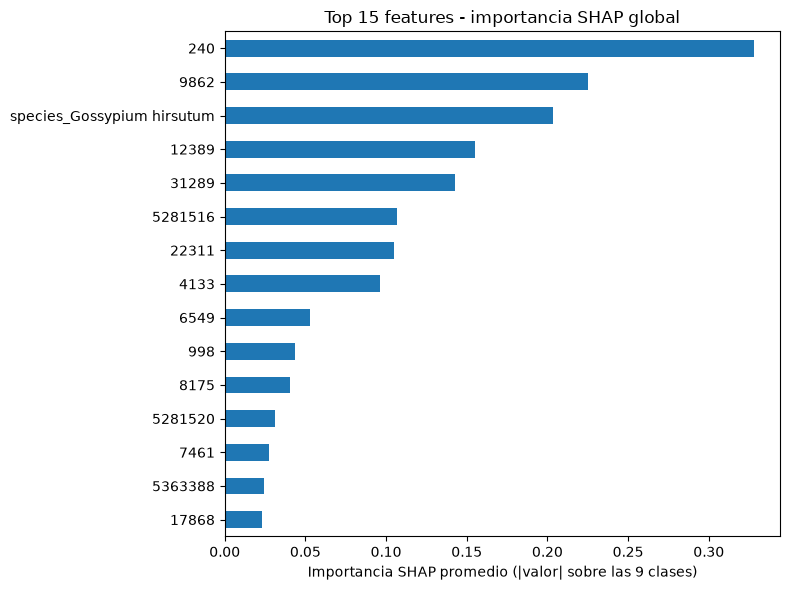

In [47]:
plt.figure(figsize=(8, 6))
importancia_global.head(15).sort_values().plot(kind="barh")
plt.xlabel("Importancia SHAP promedio (|valor| sobre las 9 clases)")
plt.title("Top 15 features - importancia SHAP global")
plt.tight_layout()
plt.show()

In [48]:
# Buscar el indice de 'infected' y 'control' en las clases del modelo
idx_infected = list(le.classes_).index("infected")
idx_control = list(le.classes_).index("control")

# Importancia especifica para la clase 'infected'
shap_infected = shap_values_array[:, :, idx_infected]
importancia_infected = pd.Series(
    np.abs(shap_infected).mean(axis=0), index=X_test_limpio.columns
).sort_values(ascending=False)

print("Top 10 features que mas influyen en predecir 'infected':")
print(importancia_infected.head(10))

# Importancia especifica para la clase 'control'
shap_control = shap_values_array[:, :, idx_control]
importancia_control = pd.Series(
    np.abs(shap_control).mean(axis=0), index=X_test_limpio.columns
).sort_values(ascending=False)

print("\nTop 10 features que mas influyen en predecir 'control':")
print(importancia_control.head(10))

Top 10 features que mas influyen en predecir 'infected':
240        1.439975
18554      0.115775
23204      0.098276
5281515    0.075895
998        0.074403
6549       0.057587
7463       0.047002
12389      0.031295
31253      0.027514
2758       0.023391
dtype: float32

Top 10 features que mas influyen en predecir 'control':
240        0.455302
12389      0.131517
6549       0.108636
5281516    0.086067
9862       0.073445
6654       0.062387
31289      0.050980
957        0.044088
998        0.037325
6054       0.027750
dtype: float32


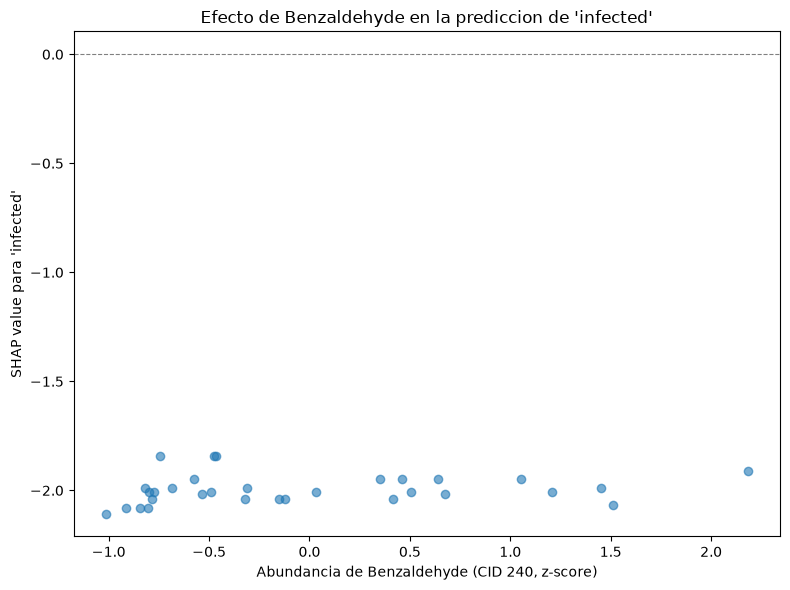

In [50]:
# Buscar la posicion de la columna "240" dentro de X_test_limpio
idx_240 = list(X_test_limpio.columns).index("240")

plt.figure(figsize=(8, 6))
plt.scatter(X_test_limpio["240"], shap_infected[:, idx_240], alpha=0.6)
plt.xlabel("Abundancia de Benzaldehyde (CID 240, z-score)")
plt.ylabel("SHAP value para 'infected'")
plt.title("Efecto de Benzaldehyde en la prediccion de 'infected'")
plt.axhline(0, color="gray", linestyle="--", linewidth=0.8)
plt.tight_layout()
plt.show()

In [51]:
# Verificar si (CID 240) tiene algun valor real para las clases control/infected
muestras_control_infected = muestras[muestras["physiological_state"].isin(["control", "infected"])]["sample_id"]

valores_240 = matriz_xgb.loc[matriz_xgb.index.isin(muestras_control_infected), 240]
print(f"Valores no-nulos de CID 240 en muestras control/infected: {valores_240.notna().sum()} de {len(valores_240)}")

# Y para confirmar, que datasets SI tienen valor real de CID 240
tiene_240 = abundancias_cid[abundancias_cid["pubchem_cid"] == 240]["dataset_origin"].unique()
print(f"Datasets que SI miden CID 240: {tiene_240}")

Valores no-nulos de CID 240 en muestras control/infected: 32 de 167
Datasets que SI miden CID 240: <ArrowStringArray>
['Ayelo2026', 'Ghosh2022', 'Moreira2024']
Length: 3, dtype: str


Al analizar el SHAP de Benzaldehyde (CID 240) para la clase `infected`, se detecto que aunque este compuesto esta en la lista de "31
compartidos entre 2+ datasets", **no esta medido en ninguna muestra de `infected`** (Laupheimer2024/Lazazzara2018).
El criterio "compartido entre 2+ datasets" no es suficiente para garantizar ausencia de señal de batch en un problema
multiclase. 

In [52]:
# Revisar para los 31 compuestos compartidos, si tiene cobertura en Lazazzara2018 como en Laupheimer2024 (control/infected)

ids_control_infected = muestras[muestras["dataset_origin"].isin(["Lazazzara2018", "Laupheimer2024"])]["sample_id"]

cobertura_por_dataset = abundancias_cid[
    (abundancias_cid["pubchem_cid"].astype(str).isin(cids_compartidos)) &
    (abundancias_cid["dataset_origin"].isin(["Lazazzara2018", "Laupheimer2024"]))
].groupby(["pubchem_cid", "dataset_origin"]).size().unstack(fill_value=0)

print("Cobertura de cada compuesto compartido, en Lazazzara2018 y Laupheimer2024:")
print(cobertura_por_dataset)

# Los que tienen datos reales en smbos
validos_control_infected = cobertura_por_dataset[
    (cobertura_por_dataset.get("Lazazzara2018", 0) > 0) &
    (cobertura_por_dataset.get("Laupheimer2024", 0) > 0)
].index.tolist()

print(f"\nDe los 31 compartidos, cuantos SI estan en ambos (Lazazzara Y Laupheimer): {len(validos_control_infected)}")
print(f"CIDs validos para distinguir control/infected sin batch: {validos_control_infected}")

Cobertura de cada compuesto compartido, en Lazazzara2018 y Laupheimer2024:
dataset_origin  Laupheimer2024  Lazazzara2018
pubchem_cid                                  
244                          0             98
957                          0             98
998                          0             98
2758                        32              0
4133                        32              0
6054                         0             98
6549                        32             98
6654                        32              0
7463                        32              0
7720                        32              0
8175                        32             98
9862                        32              0
9895                         0             98
11463                        0             98
12389                       32              0
18554                        0             98
19602                        0             98
22311                       32              0
23204